In [234]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import astropy.constants as const
import glob
print(const.k_B)
from set_rcParams import set_rcParams
set_rcParams()

  Name   = Boltzmann constant
  Value  = 1.380649e-23
  Uncertainty  = 0.0
  Unit  = J / K
  Reference = CODATA 2018


In [235]:

def f_M(v, T, m):
  return 4 * np.pi * v**2 * (m / (2 * np.pi * const.k_B.value * T))**(3/2) * np.exp(- m * v**2 / (2 * const.k_B.value * T))

alpha_range = np.linspace(0, 6000, 200)
beta_range = np.linspace(0, 2500, 200)
m = 6.6e-27
T_a = 1000
T_b = 100

alpha_actual_dist = f_M(alpha_range, T_a, m)
beta_actual_dist = f_M(beta_range, T_b, m)

In [236]:
data = pd.read_csv("testing_out_velocities_0005.csv")


In [237]:
alpha = data[data["species"] == 0]
beta = data[data["species"] == 1]

def speed_from_df(df):
  return  np.sqrt(df["v_x"]**2 +  df["v_y"]**2 +  df["v_z"]**2)

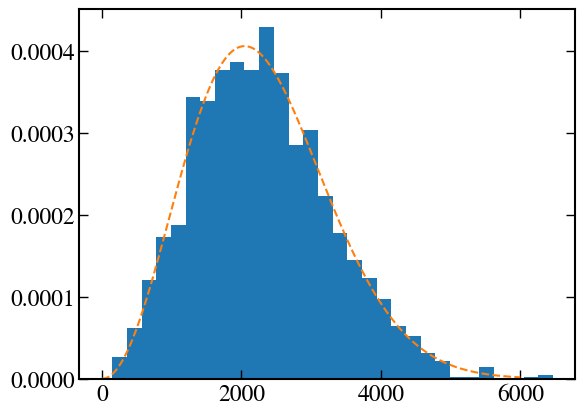

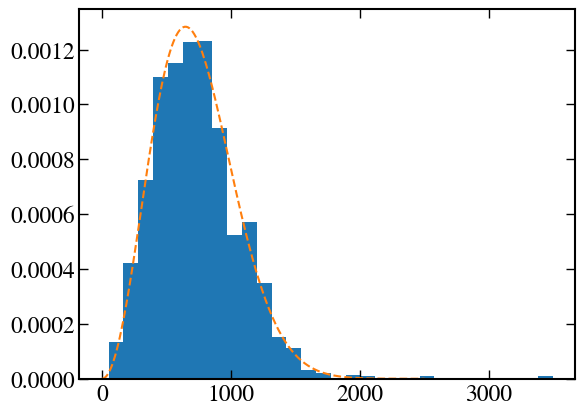

In [238]:

alpha_speed = speed_from_df(alpha)

beta_speed = speed_from_df(beta)

plt.figure()
plt.hist(alpha_speed, bins=30, density=True)
plt.plot(alpha_range, alpha_actual_dist, '--')
plt.show()



plt.figure()
plt.hist(beta_speed, bins=30, density=True)
plt.plot(beta_range, beta_actual_dist, '--')
plt.show()

In [239]:
def temp_from_mean_speed(speed_array, mass : float = m) -> float:
  return (1/3) * mass * (speed_array**2).mean() / const.k_B.value

In [240]:
T_alpha = temp_from_mean_speed(alpha_speed)
print(T_alpha)

T_beta = temp_from_mean_speed(beta_speed)
print(T_beta)

1000.0713237898061
102.60346413401251


In [241]:
files = sorted(glob.glob("testing_out_*.csv"))[1:]

alpha_T = []
beta_T = []
time = []
for f in files:
  data = pd.read_csv(f)

  alpha = data[data["species"] == 0]
  beta = data[data["species"] == 1]
  time.append(data["t_vel"][0])

  alpha_T.append(temp_from_mean_speed(speed_from_df(alpha)))
  beta_T.append(temp_from_mean_speed(speed_from_df(beta)))

time = np.array(time)
alpha_T = np.array(alpha_T)
beta_T = np.array(beta_T)

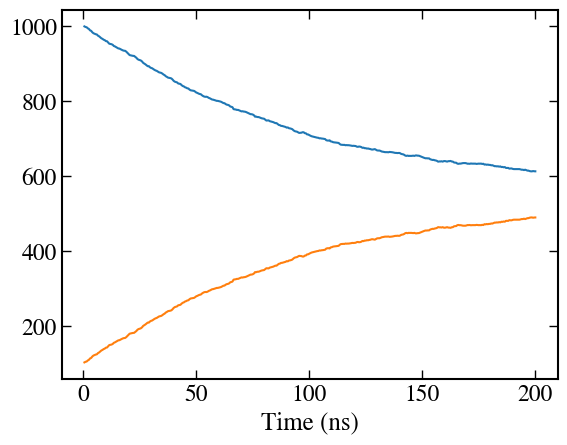

In [242]:
plt.figure()
plt.plot(time * 1e9, alpha_T)
plt.plot(time * 1e9, beta_T)
plt.xlabel("Time (ns)")
plt.show()

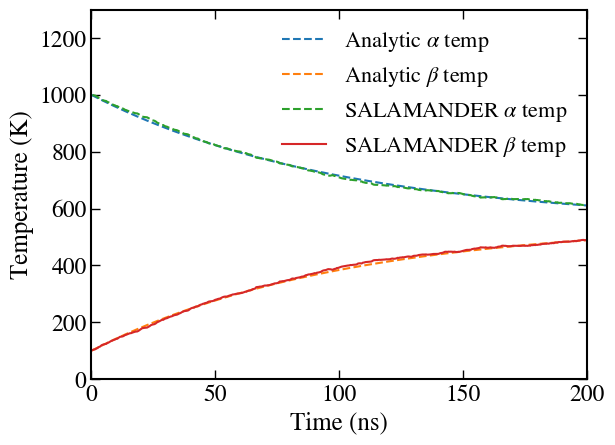

In [249]:
def calc_nu_ab(m_a, m_b, sigma_0, n):
  M = m_a + m_b
  m_ab = m_a * m_b / M
  return m_ab / (m_a + m_b) * 3 * n * sigma_0

def T_alpha(nu_ab, t):
  return 550 + 450 * np.exp(-4/3 * nu_ab * t)

def T_beta(nu_ab, t):
  return 550 - 450 * np.exp(-4/3 * nu_ab * t)

m = 6.646764e-27
m_a = m
m_b = m
sigma_0 = 1e-18
n = 1e25
nu_ab = calc_nu_ab(m_a, m_b, sigma_0, n)

t = np.arange(0, 200e-9, 0.1e-9)

plt.figure()
plt.plot(t * 1e9, T_alpha(nu_ab, t), '--', label="Analytic $\\alpha$ temp")
plt.plot(t * 1e9, T_beta(nu_ab, t), '--', label="Analytic $\\beta$ temp")
plt.plot(time * 1e9, alpha_T, '--', label="SALAMANDER $\\alpha$ temp")
plt.plot(time * 1e9, beta_T, label="SALAMANDER $\\beta$ temp")
plt.xlabel("Time (ns)")
plt.ylabel("Temperature (K)")
plt.ylim(bottom=0, top=1300)
plt.xlim(left=0, right=200)
plt.legend()
plt.show()